# Meta-learning paper plots with MAML checkpoint variants

This notebook is a sibling of `MetaPaperPlotsPerTaskWithMAML.ipynb`. It reuses the same per-task plotting structure, keeps the old MAML curve, and adds slots for four new MAML variants on linear regression and decision trees.

Use the config cell below to paste run keys and choose checkpoints. Set a checkpoint selector to `"latest"` to load `state.pt`, or to an integer step such as `50000` to load `model_50000.pt`.


In [1]:
import ast
import json
import os
import sys
from pathlib import Path

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().resolve().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.environ.setdefault("HF_HOME", "/mnt/nlp/scratch/home/mpanwar/.cache/huggingface/hf-home")


'/mnt/nlp/scratch/home/mpanwar/.cache/huggingface/hf-home'

In [2]:
import sys
print(sys.executable)

/mnt/nlp/scratch/home/mpanwar/.venv/bin/python


In [3]:
import importlib

import base_models as base_models_module
import eval as eval_module
import meta_eval as meta_eval_module
import models as models_module
import plot_meta_paper_figure as meta_plots

# Reload local modules so notebook reruns pick up source edits without restarting the kernel.
meta_eval_module = importlib.reload(meta_eval_module)
eval_module = importlib.reload(eval_module)
base_models_module = importlib.reload(base_models_module)
models_module = importlib.reload(models_module)
meta_plots = importlib.reload(meta_plots)

from eval import get_model_from_run, get_run_metrics
from plot_meta_paper_figure import (
    TASK_SPECS,
    find_latest_run,
    get_error_normalization,
    plot_task,
    rename_model,
)

task_metrics = {}
figures = {}


## Evaluation notes

The baseline curves are plotted exactly as in the original notebook. For latest ICL checkpoints, the notebook loads cached ICL and baseline curves when possible. If you choose a step checkpoint for an ICL model, the notebook evaluates that step with the standard eval and includes the same baselines.

The old and new meta-learning curves use the current `maml` eval from `src/eval.py`/`src/meta_eval.py`, not the stale outputs embedded in the old notebook. By default, MAML cache reuse is disabled so learned inner-loop learning rates and `conf.meta.num_inner_steps` are read from each selected checkpoint/config and evaluated with the current code. Each MAML run can independently use `"latest"` (`state.pt`) or a kept step checkpoint (`model_<step>.pt`). The new MAML variants are included only for linear regression and decision trees, and only after their run keys are filled in.


In [4]:
ICL_EVAL_NAME = "standard"
MAML_EVAL_NAME = "maml"

# Latest ICL/baseline curves are cache-only in this notebook.
# Step-specific ICL checkpoints are evaluated through get_run_metrics(..., step=...).
ICL_CACHE_ONLY = True

# Toggle this before running plot cells.
# True reuses metrics.json / metrics_<step>.json where available; False refreshes MAML evals.
PLOT_USE_CACHE = True

# Backwards-compatible alias used by helper code below.
MAML_USE_CACHE = PLOT_USE_CACHE

# -----------------------------------------------------------------------------
# Existing runs copied from MetaPaperPlotsPerTaskWithMAML.ipynb.
# -----------------------------------------------------------------------------
LINEAR_MAML_RUN = "1541c24b-e0c6-4c29-9dfe-49ff15e6e437"
SPARSE_MAML_RUN = "8c5cff2f-cd47-4a9c-8228-afdb9596826b"
TREE_MAML_RUN = "032c4021-c5c7-49e8-b00d-4f9dd6ea898b"
RELU_MAML_RUN = "a6e7479c-0345-44bf-97a3-ceeabfb48dc9"

LINEAR_ICL_RUN = "12cc04e3-c831-488a-ac34-0d8388192559"
SPARSE_ICL_RUN = "1bbcaa69-fe39-4335-abb2-28172861bf5a"
TREE_ICL_RUN = "3cf4987d-48cd-407f-b874-a882c49e9331"
RELU_ICL_RUN = "9f5157b6-5ca2-420d-a9fe-4dd30d619dda"

# -----------------------------------------------------------------------------
# New MAML variants. Paste run keys here when available.
# Leave as None or "" to skip that curve.
# -----------------------------------------------------------------------------
LINEAR_MAML_1STEP_LEARNED_LR_RUN = "04bf15e2-2631-45bf-a821-746d8d003a58"
LINEAR_MAML_2STEP_LEARNED_LR_RUN = "aafe2ed7-7e04-420e-b733-ee2334b900fe"
LINEAR_FOMAML_2STEP_LEARNED_LR_RUN = "a3d60aba-71ea-49cc-8375-cb085bf97c89"
LINEAR_MAML_1STEP_LEARNED_LR_MULTI_K_RUN = "b7db4b1e-0f26-42b3-aa9b-6b9df4793916"
LINEAR_MAML_2STEP_LEARNED_LR_MULTI_K_RUN = "d0a4c860-5f8d-445b-997f-13543b957363"


TREE_MAML_1STEP_LEARNED_LR_RUN = "8a96b227-45c9-44b6-9170-da40b25b701a"
TREE_MAML_2STEP_LEARNED_LR_RUN = "8e762a47-93c1-4f16-a670-cfdd2e694f7b"
TREE_FOMAML_2STEP_LEARNED_LR_RUN = "4df26561-ae9a-42e7-8c7e-944f8009ab4e"
TREE_MAML_1STEP_LEARNED_LR_MULTI_K_24k_RUN = "bc743acc-ad36-43de-bb42-63a46457f215"
# TREE_MAML_2STEP_LEARNED_LR_MULTI_K_16k_RUN = "1132aae4-769b-4a9e-862d-9f30f78d96f7"
TREE_MAML_2STEP_LEARNED_LR_MULTI_K_16k_RUN = "16170709-b0f6-4f92-bda6-04651ae15db2"

# -----------------------------------------------------------------------------
# Checkpoint selectors. Use "latest" for state.pt, or an integer for model_<step>.pt.
# -----------------------------------------------------------------------------
LINEAR_ICL_CHECKPOINT = "latest"
SPARSE_ICL_CHECKPOINT = "latest"
TREE_ICL_CHECKPOINT = "latest"
RELU_ICL_CHECKPOINT = "latest"

LINEAR_MAML_CHECKPOINT = "latest"
SPARSE_MAML_CHECKPOINT = "latest"
TREE_MAML_CHECKPOINT = "latest"
RELU_MAML_CHECKPOINT = "latest"

LINEAR_MAML_1STEP_LEARNED_LR_CHECKPOINT = 500001
LINEAR_MAML_2STEP_LEARNED_LR_CHECKPOINT = 300000
LINEAR_FOMAML_2STEP_LEARNED_LR_CHECKPOINT = 500001
LINEAR_MAML_1STEP_LEARNED_LR_MULTI_K_CHECKPOINT = 250000
LINEAR_MAML_2STEP_LEARNED_LR_MULTI_K_CHECKPOINT = "latest"


TREE_MAML_1STEP_LEARNED_LR_CHECKPOINT = 350000
TREE_MAML_2STEP_LEARNED_LR_CHECKPOINT = 200000
TREE_FOMAML_2STEP_LEARNED_LR_CHECKPOINT = 400000
TREE_MAML_1STEP_LEARNED_LR_MULTI_K_24k_CHECKPOINT = "latest"
TREE_MAML_2STEP_LEARNED_LR_MULTI_K_16k_CHECKPOINT = "latest"


RUN_ROOTS = {
    "maml": {
        "linear_regression": REPO_ROOT / "models" / "meta_linear_regression",
        "sparse_linear_regression": REPO_ROOT / "models" / "meta_sparse_linear_regression",
        "decision_tree": REPO_ROOT / "models" / "meta_decision_tree",
        "relu_2nn_regression": REPO_ROOT / "models" / "meta_relu_2nn_regression",
    },
    "icl": {
        "linear_regression": REPO_ROOT / "models" / "linear_regression",
        "sparse_linear_regression": REPO_ROOT / "models" / "sparse_linear_regression",
        "decision_tree": REPO_ROOT / "models" / "decision_tree",
        "relu_2nn_regression": REPO_ROOT / "models" / "relu_2nn_regression",
    },
}

ICL_RUN_CONFIGS = {
    "linear_regression": {"run": LINEAR_ICL_RUN, "checkpoint": LINEAR_ICL_CHECKPOINT},
    "sparse_linear_regression": {"run": SPARSE_ICL_RUN, "checkpoint": SPARSE_ICL_CHECKPOINT},
    "decision_tree": {"run": TREE_ICL_RUN, "checkpoint": TREE_ICL_CHECKPOINT},
    "relu_2nn_regression": {"run": RELU_ICL_RUN, "checkpoint": RELU_ICL_CHECKPOINT},
}

OLD_MAML_RUN_CONFIGS = {
    "linear_regression": {"run": LINEAR_MAML_RUN, "checkpoint": LINEAR_MAML_CHECKPOINT},
    "sparse_linear_regression": {"run": SPARSE_MAML_RUN, "checkpoint": SPARSE_MAML_CHECKPOINT},
    "decision_tree": {"run": TREE_MAML_RUN, "checkpoint": TREE_MAML_CHECKPOINT},
    "relu_2nn_regression": {"run": RELU_MAML_RUN, "checkpoint": RELU_MAML_CHECKPOINT},
}

MAML_1STEP_LEARNED_LR_EXPECTED_META = {
    "inner_lr_mode": "learned_per_param",
    "num_inner_steps": 1,
}
MAML_2STEP_LEARNED_LR_EXPECTED_META = {
    "inner_lr_mode": "learned_per_param",
    "num_inner_steps": 2,
}
MAML_1STEP_LEARNED_LR_MULTI_K_EXPECTED_META = {
    "inner_lr_mode": "learned_per_param",
    "num_inner_steps": 1,
    "multi_k_support": True,
}
MAML_2STEP_LEARNED_LR_MULTI_K_EXPECTED_META = {
    "inner_lr_mode": "learned_per_param",
    "num_inner_steps": 2,
    "multi_k_support": True,
}

MAML_VARIANT_CONFIGS = {
    "linear_regression": [
        {
            "label": "Transformer (MAML, 1 step, learned LR)",
            "run": LINEAR_MAML_1STEP_LEARNED_LR_RUN,
            "checkpoint": LINEAR_MAML_1STEP_LEARNED_LR_CHECKPOINT,
            "expected_meta": MAML_1STEP_LEARNED_LR_EXPECTED_META,
        },
        {
            "label": "Transformer (MAML, 2 steps, learned LR)",
            "run": LINEAR_MAML_2STEP_LEARNED_LR_RUN,
            "checkpoint": LINEAR_MAML_2STEP_LEARNED_LR_CHECKPOINT,
            "expected_meta": MAML_2STEP_LEARNED_LR_EXPECTED_META,
        },
        {
            "label": "Transformer (FOMAML, 2 steps, learned LR)",
            "run": LINEAR_FOMAML_2STEP_LEARNED_LR_RUN,
            "checkpoint": LINEAR_FOMAML_2STEP_LEARNED_LR_CHECKPOINT,
            "expected_meta": MAML_2STEP_LEARNED_LR_EXPECTED_META,
        },
        {
            "label": "Transformer (MAML, 1 step, learned LR, multi-k support)",
            "run": LINEAR_MAML_1STEP_LEARNED_LR_MULTI_K_RUN,
            "checkpoint": LINEAR_MAML_1STEP_LEARNED_LR_MULTI_K_CHECKPOINT,
            "expected_meta": MAML_1STEP_LEARNED_LR_MULTI_K_EXPECTED_META,
        },
        {
            "label": "Transformer (MAML, 2 steps, learned LR, multi-k support)",
            "run": LINEAR_MAML_2STEP_LEARNED_LR_MULTI_K_RUN,
            "checkpoint": LINEAR_MAML_2STEP_LEARNED_LR_MULTI_K_CHECKPOINT,
            "expected_meta": MAML_2STEP_LEARNED_LR_MULTI_K_EXPECTED_META,
        },
    ],
    "decision_tree": [
        {
            "label": "Transformer (MAML, 1 step, learned LR)",
            "run": TREE_MAML_1STEP_LEARNED_LR_RUN,
            "checkpoint": TREE_MAML_1STEP_LEARNED_LR_CHECKPOINT,
            "expected_meta": MAML_1STEP_LEARNED_LR_EXPECTED_META,
        },
        {
            "label": "Transformer (MAML, 2 steps, learned LR)",
            "run": TREE_MAML_2STEP_LEARNED_LR_RUN,
            "checkpoint": TREE_MAML_2STEP_LEARNED_LR_CHECKPOINT,
            "expected_meta": MAML_2STEP_LEARNED_LR_EXPECTED_META,
        },
        {
            "label": "Transformer (FOMAML, 2 steps, learned LR)",
            "run": TREE_FOMAML_2STEP_LEARNED_LR_RUN,
            "checkpoint": TREE_FOMAML_2STEP_LEARNED_LR_CHECKPOINT,
            "expected_meta": MAML_2STEP_LEARNED_LR_EXPECTED_META,
        },
        {
            "label": "Transformer (MAML, 1 step, learned LR, multi-k support, 24k steps)",
            "run": TREE_MAML_1STEP_LEARNED_LR_MULTI_K_24k_RUN,
            "checkpoint": TREE_MAML_1STEP_LEARNED_LR_MULTI_K_24k_CHECKPOINT,
            "expected_meta": MAML_1STEP_LEARNED_LR_MULTI_K_EXPECTED_META,
        },
        {
            "label": "Transformer (MAML, 2 steps, learned LR, multi-k support, 16k steps)",
            "run": TREE_MAML_2STEP_LEARNED_LR_MULTI_K_16k_RUN,
            "checkpoint": TREE_MAML_2STEP_LEARNED_LR_MULTI_K_16k_CHECKPOINT,
            "expected_meta": MAML_2STEP_LEARNED_LR_MULTI_K_EXPECTED_META,
        },
    ],
}


In [5]:
BASE_MODEL_ORDERS = {
    "linear_regression": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "Least Squares",
        "3-Nearest Neighbors",
        "Averaging",
    ],
    "sparse_linear_regression": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "Least Squares",
        "Averaging",
        "Lasso (alpha=0.01)",
    ],
    "decision_tree": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "3-Nearest Neighbors",
        "Greedy Tree Learning",
        "XGBoost",
        "Greedy Tree Learning\n(w/ sign preproc.)",
        "XGBoost\n(w/ sign preproc.)",
    ],
    "relu_2nn_regression": [
        "Transformer (ICL)",
        "Transformer (MAML)",
        "Least Squares",
        "3-Nearest Neighbors",
        "2-layer NN, GD",
    ],
}

VARIANT_LABELS = {
    task_name: [cfg["label"] for cfg in configs]
    for task_name, configs in MAML_VARIANT_CONFIGS.items()
}

MODEL_ORDERS = {
    task_name: (
        BASE_MODEL_ORDERS[task_name][:2]
        + VARIANT_LABELS.get(task_name, [])
        + BASE_MODEL_ORDERS[task_name][2:]
    )
    for task_name in BASE_MODEL_ORDERS
}

# The source notebook's plotted return values are used only when a latest ICL run lacks metrics.json.
SOURCE_NOTEBOOK = REPO_ROOT / "EvalNotebooks" / "MetaPaperPlotsPerTask.ipynb"
SOURCE_OUTPUT_CELLS = {
    "linear_regression": 9,
    "sparse_linear_regression": 11,
    "decision_tree": 13,
    "relu_2nn_regression": 15,
}

# Match the ICL run's evaluation batch size; this affects batching, not the task distribution.
MAML_EVAL_OVERRIDES = {
    "linear_regression": {"batch_size": 64},
    "sparse_linear_regression": {"batch_size": 64},
    "decision_tree": {"batch_size": 64},
    "relu_2nn_regression": {"batch_size": 64},
}


In [6]:
def checkpoint_to_step(selector):
    if selector is None or selector == "latest":
        return -1
    if isinstance(selector, str):
        selector = selector.strip()
        if selector.lower() == "latest":
            return -1
        if selector.isdigit():
            return int(selector)
    if isinstance(selector, int):
        return selector
    raise ValueError(f"Checkpoint selector must be 'latest' or an integer step, got {selector!r}")


def checkpoint_file_name(selector):
    step = checkpoint_to_step(selector)
    return "state.pt" if step == -1 else f"model_{step}.pt"


def resolve_run_path(family, task_name, run_key):
    if run_key in [None, ""]:
        return None
    run_path = Path(run_key)
    if not run_path.is_absolute():
        run_path = RUN_ROOTS[family][task_name] / run_path
    return run_path


def resolve_model_config(family, task_name, cfg):
    run_path = resolve_run_path(family, task_name, cfg["run"])
    if run_path is None:
        return None
    checkpoint = cfg.get("checkpoint", "latest")
    ckpt_path = run_path / checkpoint_file_name(checkpoint)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing checkpoint for {task_name}: {ckpt_path}")
    return {
        "run_path": run_path,
        "checkpoint": checkpoint,
        "step": checkpoint_to_step(checkpoint),
        "checkpoint_path": ckpt_path,
    }


resolved_icl = {
    task_name: resolve_model_config("icl", task_name, cfg)
    for task_name, cfg in ICL_RUN_CONFIGS.items()
}
resolved_old_maml = {
    task_name: resolve_model_config("maml", task_name, cfg)
    for task_name, cfg in OLD_MAML_RUN_CONFIGS.items()
}
resolved_maml_variants = {
    task_name: [
        {**variant_cfg, **resolved}
        for variant_cfg in variant_cfgs
        for resolved in [resolve_model_config("maml", task_name, variant_cfg)]
        if resolved is not None
    ]
    for task_name, variant_cfgs in MAML_VARIANT_CONFIGS.items()
}

print("ICL runs:")
for task_name, cfg in resolved_icl.items():
    print(f"  {task_name}: {cfg['run_path']} [{checkpoint_file_name(cfg['checkpoint'])}]")

print("\nOld MAML runs:")
for task_name, cfg in resolved_old_maml.items():
    print(f"  {task_name}: {cfg['run_path']} [{checkpoint_file_name(cfg['checkpoint'])}]")

print("\nNew MAML variant runs:")
for task_name, cfgs in resolved_maml_variants.items():
    if not cfgs:
        print(f"  {task_name}: no new variant keys set")
    for cfg in cfgs:
        print(f"  {task_name}: {cfg['label']} -> {cfg['run_path']} [{checkpoint_file_name(cfg['checkpoint'])}]")


ICL runs:
  linear_regression: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559 [state.pt]
  sparse_linear_regression: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/sparse_linear_regression/1bbcaa69-fe39-4335-abb2-28172861bf5a [state.pt]
  decision_tree: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/decision_tree/3cf4987d-48cd-407f-b874-a882c49e9331 [state.pt]
  relu_2nn_regression: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/relu_2nn_regression/9f5157b6-5ca2-420d-a9fe-4dd30d619dda [state.pt]

Old MAML runs:
  linear_regression: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/1541c24b-e0c6-4c29-9dfe-49ff15e6e437 [state.pt]
  sparse_linear_regression: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_sparse_linear_regression/8c5cff2f-cd47-4a9c-8228-afdb9596826b [state.pt]
  decision_tree: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_deci

In [7]:
def _normalize_and_rename_eval(raw_eval_metrics, run_path, transformer_label):
    _, conf = get_model_from_run(str(run_path), only_conf=True)
    normalization = get_error_normalization(conf)
    renamed = {}
    for model_name, model_metrics in raw_eval_metrics.items():
        renamed_model = rename_model(model_name, conf, transformer_label=transformer_label)
        renamed[renamed_model] = {
            key: [value / normalization for value in values]
            for key, values in model_metrics.items()
        }
    return renamed


def _extract_metrics_from_source_notebook(task_name):
    nb = json.loads(SOURCE_NOTEBOOK.read_text())
    cell = nb["cells"][SOURCE_OUTPUT_CELLS[task_name]]
    for output in cell.get("outputs", []):
        text = "".join(output.get("data", {}).get("text/plain", []))
        stripped = text.strip()
        figure_idx = stripped.rfind("<Figure")
        if stripped.startswith("({") and figure_idx != -1:
            metrics_text = stripped[1:figure_idx].rstrip()
            if metrics_text.endswith(","):
                metrics_text = metrics_text[:-1].rstrip()
            return ast.literal_eval(metrics_text)
    raise FileNotFoundError(
        f"No cached execute_result metrics found for {task_name} in {SOURCE_NOTEBOOK}"
    )


def get_task_metrics_for_checkpoint(
    run_path,
    eval_name,
    checkpoint="latest",
    cache=True,
    transformer_label="Transformer",
    skip_baselines=False,
    baseline_models=None,
    baseline_model_names=None,
    eval_kwargs_overrides=None,
    normalize=True,
):
    step = checkpoint_to_step(checkpoint)
    metrics = get_run_metrics(
        str(run_path),
        step=step,
        cache=cache,
        skip_baselines=skip_baselines,
        eval_names=[eval_name],
        baseline_models=baseline_models,
        baseline_model_names=baseline_model_names,
        eval_kwargs_overrides=eval_kwargs_overrides,
    )
    if eval_name not in metrics:
        metrics_file = "metrics.json" if step == -1 else f"metrics_{step}.json"
        raise KeyError(
            f"Eval '{eval_name}' not found in {run_path / metrics_file}. "
            f"Available evals: {list(metrics.keys())}"
        )
    if normalize:
        return _normalize_and_rename_eval(metrics[eval_name], run_path, transformer_label)
    return metrics[eval_name]


def load_cached_latest_icl_metrics(task_name):
    icl_cfg = resolved_icl[task_name]
    icl_run = icl_cfg["run_path"]
    metrics_path = icl_run / "metrics.json"
    required_models = set(BASE_MODEL_ORDERS[task_name]) - {"Transformer (MAML)"}

    if metrics_path.exists():
        with metrics_path.open() as fp:
            all_metrics = json.load(fp)
        if ICL_EVAL_NAME in all_metrics:
            metrics = _normalize_and_rename_eval(
                all_metrics[ICL_EVAL_NAME],
                icl_run,
                transformer_label="Transformer (ICL)",
            )
            if required_models.issubset(metrics.keys()):
                print(f"  loaded cached latest ICL/baseline curves: {metrics_path}", flush=True)
                return {name: metrics[name] for name in BASE_MODEL_ORDERS[task_name] if name in metrics}
            missing = sorted(required_models - set(metrics.keys()))
            print(f"  metrics.json is missing plotted curves {missing}; falling back to source notebook output", flush=True)

    if ICL_CACHE_ONLY:
        metrics = _extract_metrics_from_source_notebook(task_name)
        print(f"  loaded cached ICL/baseline curves from source notebook output: {SOURCE_NOTEBOOK.name}", flush=True)
        return {name: metrics[name] for name in BASE_MODEL_ORDERS[task_name] if name in metrics}

    raise FileNotFoundError(f"No cache available for {task_name}: {metrics_path}")


def load_or_compute_icl_metrics(task_name):
    icl_cfg = resolved_icl[task_name]
    if icl_cfg["step"] == -1:
        return load_cached_latest_icl_metrics(task_name)

    print(
        f"  evaluating ICL/baseline curves from step checkpoint: {icl_cfg['checkpoint_path']}",
        flush=True,
    )
    return get_task_metrics_for_checkpoint(
        icl_cfg["run_path"],
        ICL_EVAL_NAME,
        checkpoint=icl_cfg["checkpoint"],
        cache=True,
        transformer_label="Transformer (ICL)",
        skip_baselines=False,
    )


def compute_maml_metrics(task_name, cfg, label, use_cache=None):
    if use_cache is None:
        use_cache = PLOT_USE_CACHE
    overrides = MAML_EVAL_OVERRIDES.get(task_name)
    _, conf = get_model_from_run(str(cfg["run_path"]), only_conf=True)
    meta = conf.meta
    print(f"  computing/loading {label}: {cfg['checkpoint_path']}", flush=True)
    print(
        "  MAML config: "
        f"inner_lr_mode={meta.get('inner_lr_mode', 'fixed')}, "
        f"inner_lr={meta.inner_lr}, "
        f"num_inner_steps={meta.num_inner_steps}",
        flush=True,
    )
    if use_cache:
        print("  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path", flush=True)
    if overrides:
        print(f"  MAML eval overrides: {overrides}", flush=True)

    return get_task_metrics_for_checkpoint(
        cfg["run_path"],
        MAML_EVAL_NAME,
        checkpoint=cfg["checkpoint"],
        cache=use_cache,
        transformer_label=label,
        skip_baselines=True,
        eval_kwargs_overrides=overrides,
    )


def compute_and_plot_task_with_maml_variants(task_name, use_cache=None, display_plot=True):
    if use_cache is None:
        use_cache = PLOT_USE_CACHE
    task_title = TASK_SPECS[task_name]["title"]
    print("\n" + "=" * 80, flush=True)
    print(f"Task: {task_title} [{task_name}]", flush=True)
    print("ICL transformer and baselines: cache for latest, eval for selected step", flush=True)
    print("Meta-learning transformers: MAML eval, baselines skipped", flush=True)

    icl_metrics = load_or_compute_icl_metrics(task_name)
    old_maml_metrics = compute_maml_metrics(
        task_name,
        resolved_old_maml[task_name],
        "Transformer (MAML)",
        use_cache=use_cache,
    )

    combined = {}
    combined.update(icl_metrics)
    combined.update(old_maml_metrics)

    for variant_cfg in resolved_maml_variants.get(task_name, []):
        combined.update(compute_maml_metrics(task_name, variant_cfg, variant_cfg["label"], use_cache=use_cache))

    task_metrics[task_name] = combined
    print(f"  curves available: {sorted(combined.keys())}", flush=True)

    fig = None
    if display_plot:
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 5.3), constrained_layout=True)
        plot_task(ax, task_name, combined, model_order=MODEL_ORDERS[task_name])
        figures[task_name] = fig
        display(fig)
        plt.close(fig)
    return combined, fig


def ensure_task_metrics(task_name, use_cache=True):
    if task_name not in task_metrics:
        compute_and_plot_task_with_maml_variants(
            task_name,
            use_cache=use_cache,
            display_plot=False,
        )
    return task_metrics[task_name]


def maml_comparison_order(task_name, include_old_maml=True):
    labels = list(VARIANT_LABELS.get(task_name, []))
    if include_old_maml:
        labels = ["Transformer (MAML)"] + labels
    return labels


def plot_cached_task_view(
    task_name,
    *,
    model_order=None,
    legend_outside=False,
    figsize=None,
    figure_key=None,
    use_cache=True,
):
    metrics = ensure_task_metrics(task_name, use_cache=use_cache)
    if model_order is None:
        model_order = MODEL_ORDERS[task_name]
    filtered_metrics = {name: metrics[name] for name in model_order if name in metrics}
    if figsize is None:
        figsize = (12.5, 5.6) if legend_outside else (8.5, 5.3)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    plot_task(ax, task_name, filtered_metrics, model_order=model_order)
    if legend_outside:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            borderaxespad=0.0,
        )
        fig.subplots_adjust(right=0.62)
    else:
        fig.tight_layout()

    if figure_key is None:
        figure_key = f"{task_name}_view"
    figures[figure_key] = fig
    display(fig)
    plt.close(fig)
    return filtered_metrics, fig


In [8]:
# Sanity check: every selected ICL/meta run for a task matches on task family,
# data distribution, dimensionality, prompt length, and task kwargs.
for task_name in BASE_MODEL_ORDERS:
    _, icl_conf = get_model_from_run(str(resolved_icl[task_name]["run_path"]), only_conf=True)
    selected_meta_runs = [("Transformer (MAML)", resolved_old_maml[task_name])]
    selected_meta_runs.extend(
        (cfg["label"], cfg) for cfg in resolved_maml_variants.get(task_name, [])
    )
    for label, meta_cfg in selected_meta_runs:
        _, maml_conf = get_model_from_run(str(meta_cfg["run_path"]), only_conf=True)
        checks = {
            "task": icl_conf.training.task == maml_conf.training.task,
            "data": icl_conf.training.data == maml_conf.training.data,
            "n_dims": icl_conf.model.n_dims == maml_conf.model.n_dims,
            "n_points": icl_conf.training.curriculum.points.end == maml_conf.training.curriculum.points.end,
            "task_kwargs": dict(icl_conf.training.get("task_kwargs", {})) == dict(maml_conf.training.get("task_kwargs", {})),
        }
        for key, expected_value in meta_cfg.get("expected_meta", {}).items():
            checks[f"meta.{key}"] = maml_conf.meta.get(key) == expected_value
        print(task_name, label, checks)
        if not all(checks.values()):
            raise ValueError(f"ICL/meta eval config mismatch for {task_name} / {label}: {checks}")


linear_regression Transformer (MAML) {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True}
linear_regression Transformer (MAML, 1 step, learned LR) {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True, 'meta.inner_lr_mode': True, 'meta.num_inner_steps': True}
linear_regression Transformer (MAML, 2 steps, learned LR) {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True, 'meta.inner_lr_mode': True, 'meta.num_inner_steps': True}
linear_regression Transformer (FOMAML, 2 steps, learned LR) {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True, 'meta.inner_lr_mode': True, 'meta.num_inner_steps': True}
linear_regression Transformer (MAML, 1 step, learned LR, multi-k support) {'task': True, 'data': True, 'n_dims': True, 'n_points': True, 'task_kwargs': True, 'meta.inner_lr_mode': True, 'meta.num_inner_steps': True, 'meta.multi_k_support': True}
linear_regression Transformer (M

## Linear regression



Task: (a) Linear regression [linear_regression]
ICL transformer and baselines: cache for latest, eval for selected step
Meta-learning transformers: MAML eval, baselines skipped
  loaded cached latest ICL/baseline curves: /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559/metrics.json
  computing/loading Transformer (MAML): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/1541c24b-e0c6-4c29-9dfe-49ff15e6e437/state.pt
  MAML config: inner_lr_mode=fixed, inner_lr=0.01, num_inner_steps=1
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}


/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/src/eval.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(state_path, map_location=_checkpoint_map_lo

  computing/loading Transformer (MAML, 1 step, learned LR): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/04bf15e2-2631-45bf-a821-746d8d003a58/model_500001.pt
  MAML config: inner_lr_mode=learned_per_param, inner_lr=0.01, num_inner_steps=1
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}



/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/src/eval.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=_checkpoint_

  computing/loading Transformer (MAML, 2 steps, learned LR): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/aafe2ed7-7e04-420e-b733-ee2334b900fe/model_300000.pt
  MAML config: inner_lr_mode=learned_per_param, inner_lr=0.01, num_inner_steps=2
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}


...

  computing/loading Transformer (MAML, 2 steps, learned LR, multi-k support): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/d0a4c860-5f8d-445b-997f-13543b957363/state.pt
  MAML config: inner_lr_mode=learned_per_param, inner_lr=0.01, num_inner_steps=2
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}



d0a4c860-5f8d-445b-997f-13543b957363:   0%|          | 0/1 [00:00<?, ?it/s]

    computing maml for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


d0a4c860-5f8d-445b-997f-13543b957363: 100%|██████████| 1/1 [01:31<00:00, 91.59s/it]

  curves available: ['3-Nearest Neighbors', 'Averaging', 'Least Squares', 'Transformer (FOMAML, 2 steps, learned LR)', 'Transformer (ICL)', 'Transformer (MAML)', 'Transformer (MAML, 1 step, learned LR)', 'Transformer (MAML, 1 step, learned LR, multi-k support)', 'Transformer (MAML, 2 steps, learned LR)', 'Transformer (MAML, 2 steps, learned LR, multi-k support)']


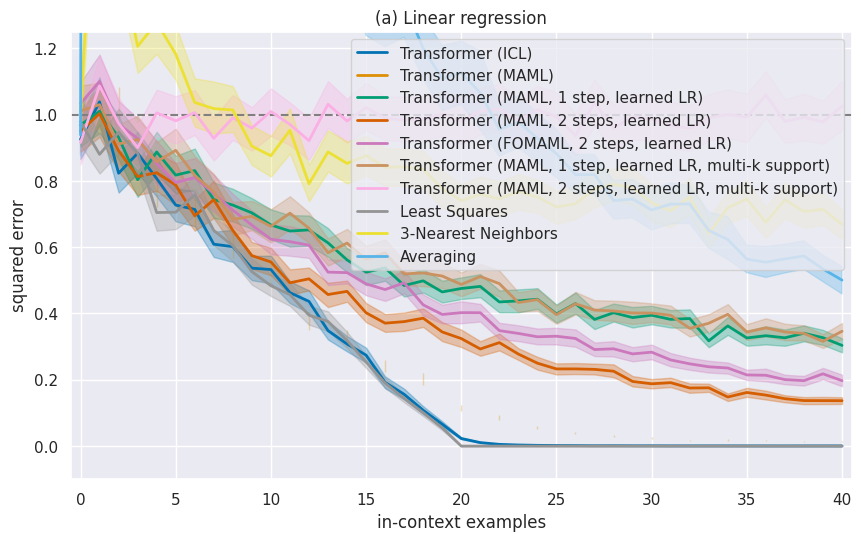

({'Transformer (ICL)': {'mean': [0.9250905036926269,
    1.038330364227295,
    0.8229291915893555,
    0.8831937789916993,
    0.8070541381835937,
    0.7270280361175537,
    0.7139287471771241,
    0.6089841842651367,
    0.6015645027160644,
    0.5367292881011962,
    0.5325091361999512,
    0.4628597259521484,
    0.4364222526550293,
    0.3483116865158081,
    0.3079838275909424,
    0.27433013916015625,
    0.19201492071151732,
    0.15619933605194092,
    0.10799511671066284,
    0.06616320610046386,
    0.022936329245567322,
    0.01055920124053955,
    0.005225907638669014,
    0.003322213888168335,
    0.0022619515657424927,
    0.0017259096726775169,
    0.0015175512060523033,
    0.0010795473121106625,
    0.001170293428003788,
    0.0009583165869116783,
    0.0009495022706687451,
    0.0007413506507873535,
    0.0007303913123905658,
    0.0007212303578853607,
    0.0007045463658869267,
    0.0006555011961609126,
    0.000626036524772644,
    0.000590697955340147,
    0.000

In [9]:
compute_and_plot_task_with_maml_variants("linear_regression", use_cache=PLOT_USE_CACHE)


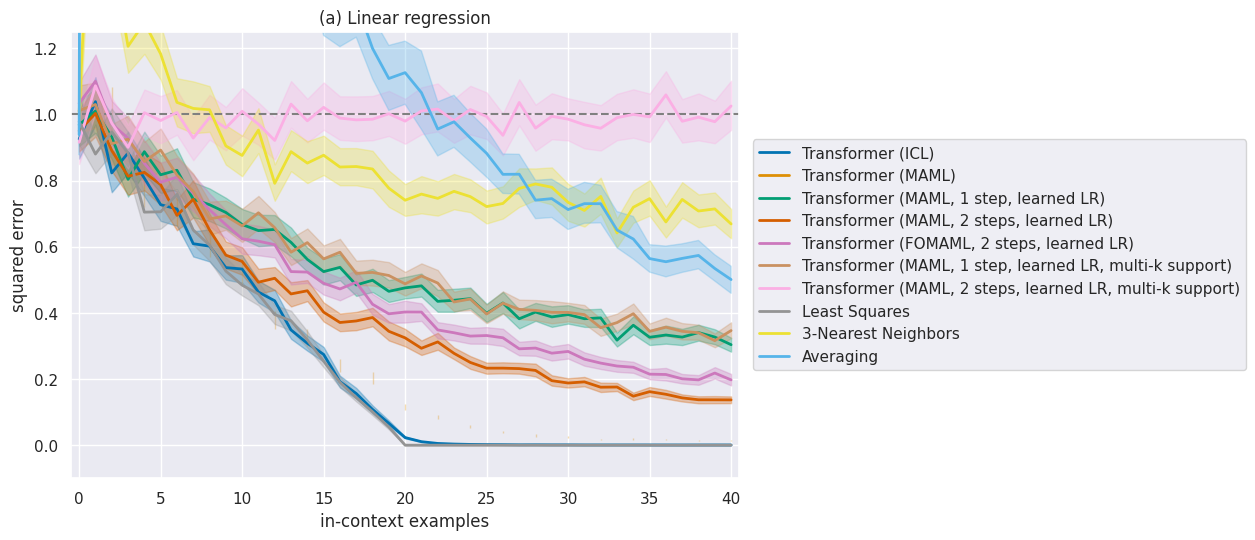

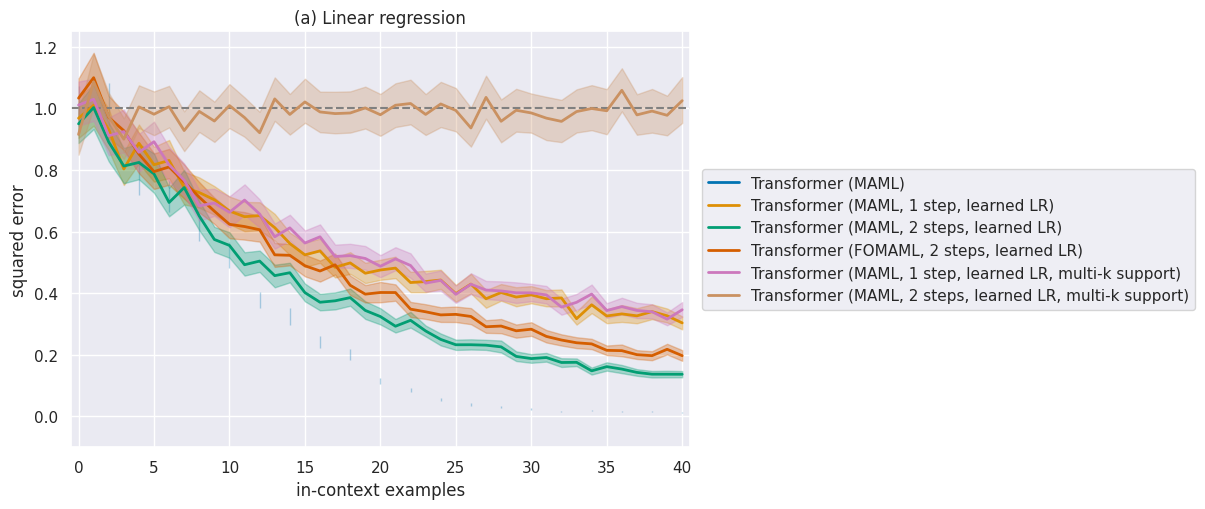

({'Transformer (MAML)': {'mean': [0.9939801216125488,
    nan,
    1.0122057914733886,
    nan,
    0.7772870063781738,
    nan,
    0.7132765293121338,
    nan,
    0.6054978370666504,
    nan,
    0.5232191562652588,
    nan,
    0.37732830047607424,
    nan,
    0.32442164421081543,
    nan,
    0.24134564399719238,
    nan,
    0.20094690322875977,
    nan,
    0.1153489112854004,
    nan,
    0.08517362475395203,
    nan,
    0.05616774559020996,
    nan,
    0.038475364446640015,
    nan,
    0.029069358110427858,
    nan,
    0.0240180104970932,
    nan,
    0.017185397446155548,
    nan,
    0.018471482396125793,
    nan,
    0.015781134366989136,
    nan,
    0.015090683102607727,
    nan,
    0.013614177703857422],
   'std': [1.5819552421569825,
    nan,
    1.586090087890625,
    nan,
    1.254783821105957,
    nan,
    1.0798256874084473,
    nan,
    0.932105827331543,
    nan,
    0.8890936851501465,
    nan,
    0.5802446365356445,
    nan,
    0.5364146709442139,
    na

In [10]:
# Cached alternate linear-regression views.
LINEAR_EXTRA_PLOTS_USE_CACHE = True

plot_cached_task_view(
    "linear_regression",
    legend_outside=True,
    figsize=(13.5, 5.8),
    figure_key="linear_regression_legend_outside",
    use_cache=LINEAR_EXTRA_PLOTS_USE_CACHE,
)

plot_cached_task_view(
    "linear_regression",
    model_order=maml_comparison_order("linear_regression"),
    legend_outside=True,
    figsize=(12.5, 5.4),
    figure_key="linear_regression_maml_variants_only",
    use_cache=LINEAR_EXTRA_PLOTS_USE_CACHE,
)


## Sparse linear regression


In [ ]:
compute_and_plot_task_with_maml_variants("sparse_linear_regression", use_cache=PLOT_USE_CACHE)


## Decision trees



Task: (c) Decision trees [decision_tree]
ICL transformer and baselines: cache for latest, eval for selected step
Meta-learning transformers: MAML eval, baselines skipped
  loaded cached ICL/baseline curves from source notebook output: MetaPaperPlotsPerTask.ipynb
  computing/loading Transformer (MAML): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/032c4021-c5c7-49e8-b00d-4f9dd6ea898b/state.pt
  MAML config: inner_lr_mode=fixed, inner_lr=0.01, num_inner_steps=1
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}


032c4021-c5c7-49e8-b00d-4f9dd6ea898b: 100%|██████████| 1/1 [00:00<00:00, 16844.59it/s]

  computing/loading Transformer (MAML, 1 step, learned LR): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/8a96b227-45c9-44b6-9170-da40b25b701a/model_350000.pt
  MAML config: inner_lr_mode=learned_per_param, inner_lr=0.01, num_inner_steps=1
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}



8a96b227-45c9-44b6-9170-da40b25b701a: 100%|██████████| 1/1 [00:00<00:00, 18396.07it/s]

  computing/loading Transformer (MAML, 2 steps, learned LR): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/8e762a47-93c1-4f16-a670-cfdd2e694f7b/model_200000.pt
  MAML config: inner_lr_mode=learned_per_param, inner_lr=0.01, num_inner_steps=2
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}


...

  computing/loading Transformer (MAML, 1 step, learned LR, multi-k support, 24k steps): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/bc743acc-ad36-43de-bb42-63a46457f215/state.pt
  MAML config: inner_lr_mode=learned_per_param, inner_lr=0.01, num_inner_steps=1
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}



bc743acc-ad36-43de-bb42-63a46457f215: 100%|██████████| 1/1 [00:00<00:00, 19972.88it/s]

  computing/loading Transformer (MAML, 2 steps, learned LR, multi-k support, 16k steps): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/16170709-b0f6-4f92-bda6-04651ae15db2/state.pt
  MAML config: inner_lr_mode=learned_per_param, inner_lr=0.01, num_inner_steps=2
  MAML cache reuse is enabled; set PLOT_USE_CACHE=False to force the current eval code path
  MAML eval overrides: {'batch_size': 64}



16170709-b0f6-4f92-bda6-04651ae15db2: 100%|██████████| 1/1 [00:00<00:00, 20460.02it/s]

  curves available: ['3-Nearest Neighbors', 'Greedy Tree Learning', 'Greedy Tree Learning\n(w/ sign preproc.)', 'Transformer (FOMAML, 2 steps, learned LR)', 'Transformer (ICL)', 'Transformer (MAML)', 'Transformer (MAML, 1 step, learned LR)', 'Transformer (MAML, 1 step, learned LR, multi-k support, 24k steps)', 'Transformer (MAML, 2 steps, learned LR)', 'Transformer (MAML, 2 steps, learned LR, multi-k support, 16k steps)', 'XGBoost', 'XGBoost\n(w/ sign preproc.)']


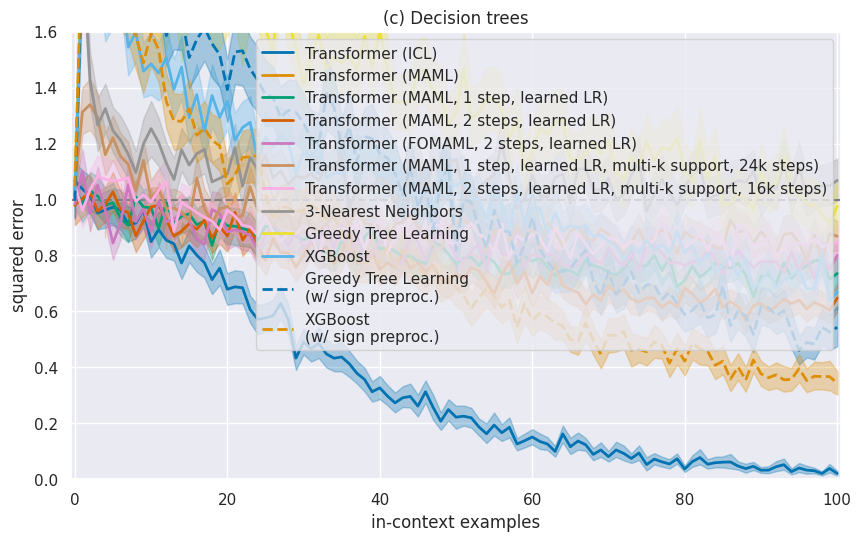

({'Transformer (ICL)': {'mean': [1.0667065382003784,
    1.037143349647522,
    1.0129938125610352,
    0.9524595141410828,
    0.9625266194343567,
    0.9726676940917969,
    0.9619248509407043,
    0.9096425771713257,
    0.9157028198242188,
    0.9640282392501831,
    0.849420428276062,
    0.8922370076179504,
    0.8544646501541138,
    0.8420241475105286,
    0.7730278968811035,
    0.8341466784477234,
    0.8007850646972656,
    0.7739654779434204,
    0.7137798070907593,
    0.754429280757904,
    0.6792235970497131,
    0.6877985000610352,
    0.684515655040741,
    0.6067046523094177,
    0.571330726146698,
    0.5769299268722534,
    0.5841747522354126,
    0.6288793683052063,
    0.5703425407409668,
    0.4330829977989197,
    0.4901501536369324,
    0.46754875779151917,
    0.4852294921875,
    0.4479209780693054,
    0.4326489567756653,
    0.43706703186035156,
    0.41303882002830505,
    0.3788558840751648,
    0.356977641582489,
    0.3126828074455261,
    0.32676017284

In [11]:
compute_and_plot_task_with_maml_variants("decision_tree", use_cache=PLOT_USE_CACHE)


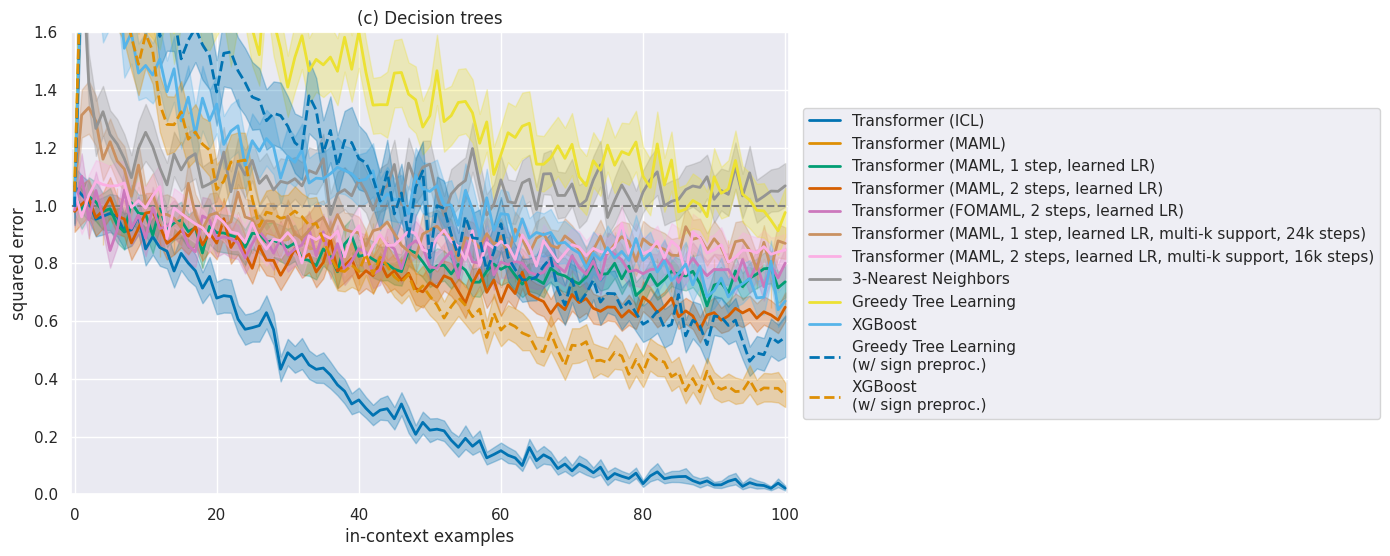

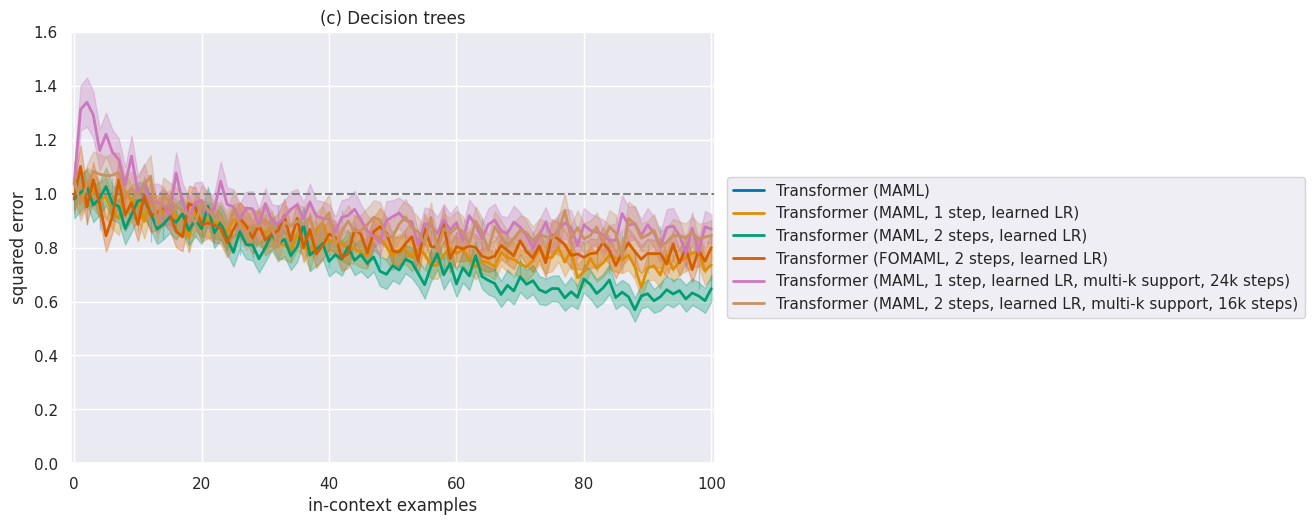

({'Transformer (MAML)': {'mean': [1.0040388107299805,
    nan,
    0.9470758438110352,
    nan,
    0.924608588218689,
    nan,
    0.9863801002502441,
    nan,
    0.9811888933181763,
    nan,
    0.9264764785766602,
    nan,
    0.872593104839325,
    nan,
    0.8957215547561646,
    nan,
    0.9272139668464661,
    nan,
    0.8371226191520691,
    nan,
    0.893325924873352,
    nan,
    0.8671358227729797,
    nan,
    0.8444240689277649,
    nan,
    0.8229123950004578,
    nan,
    0.8121161460876465,
    nan,
    0.8778848648071289,
    nan,
    0.8970561027526855,
    nan,
    0.8067363500595093,
    nan,
    0.886493980884552,
    nan,
    0.8629047274589539,
    nan,
    0.7759371399879456,
    nan,
    0.876528263092041,
    nan,
    0.8346524238586426,
    nan,
    0.8308740854263306,
    nan,
    0.7833861708641052,
    nan,
    0.8000593185424805,
    nan,
    0.8091337084770203,
    nan,
    0.7961947917938232,
    nan,
    0.8063925504684448,
    nan,
    0.765555381774

In [12]:
# Cached alternate decision-tree views.
TREE_EXTRA_PLOTS_USE_CACHE = True

plot_cached_task_view(
    "decision_tree",
    legend_outside=True,
    figsize=(14.5, 6.0),
    figure_key="decision_tree_legend_outside",
    use_cache=TREE_EXTRA_PLOTS_USE_CACHE,
)

plot_cached_task_view(
    "decision_tree",
    model_order=maml_comparison_order("decision_tree"),
    legend_outside=True,
    figsize=(13.0, 5.6),
    figure_key="decision_tree_maml_variants_only",
    use_cache=TREE_EXTRA_PLOTS_USE_CACHE,
)


## ReLU 2-layer neural networks


In [ ]:
compute_and_plot_task_with_maml_variants("relu_2nn_regression", use_cache=PLOT_USE_CACHE)


## Save outputs


In [ ]:
output_dir = REPO_ROOT / "plots"
output_dir.mkdir(parents=True, exist_ok=True)

for task_name, fig in figures.items():
    png_path = output_dir / f"{task_name}_icl-{ICL_EVAL_NAME}_maml-{MAML_EVAL_NAME}_variants.png"
    pdf_path = output_dir / f"{task_name}_icl-{ICL_EVAL_NAME}_maml-{MAML_EVAL_NAME}_variants.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)
